### 1. Derivitive

In [42]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [43]:
def f(x):
    return 3*x**2-4*x+5


In [44]:
f(3.0)

20.0

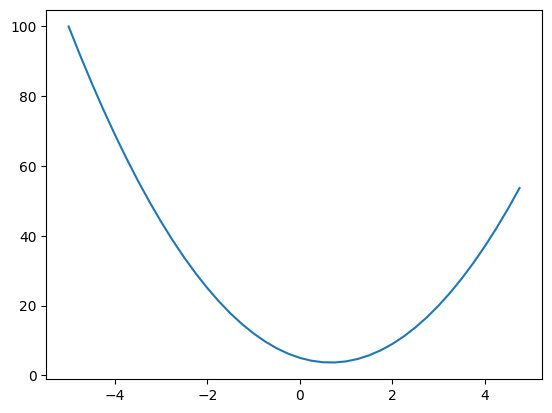

In [45]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

### 1.1 Case Example

In [46]:
h=0.0000000000000001
x=3.0
(f(x+h)-f(x))/h

0.0

In [47]:
# more complex case
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [48]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0
d1=a*b+c
a+=h # try b+=h and c+=h
d2=a*b+c

print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [49]:
class Value:

    def __init__(self,data, _children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._backward=lambda:None   # back propagation 
        self._prev=set(_children)
        self._op=_op
        self.label=label

    def __repr__(self):
        return f"Value(data={self.data},label={self.label})"
    
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward      # Caution: Don't write this into "out._backward=_backward()" as there are no return in the "_backward()", which will cause "out._backward=None"
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __rmul__(self,other):    # self*other
        return self * other

    def __truediv__(self,other): # self/other
        return self * other**-1
    
    def __neg__(self):           # -self
        return self*-1
    
    def __sub__(self,other):     # self-other
        return self+(-other)
    
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other) 
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    
    def __pow__(self,other):
        assert isinstance(other,(int,float)),"only supporting int/float powers for now"
        out=Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad+=other*(self.data**(other-1))*out.grad

        out._backward=_backward

        return out
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')
        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data
        out=Value(math.exp(),(self,),'exp')
        
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out
    
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

### 1.2 Visualization (Library Code Given)

In [50]:
# use graphviz to visualize
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [51]:
draw_dot(L)

NameError: name 'L' is not defined

### 1. Layer1：Definition of L and Gradient
$$L = d \cdot f$$

$$\frac{\partial L}{\partial f} = d = 4.0$$
$$\frac{\partial L}{\partial d} = f = -2.0$$

---

### 2. Layer2: Definition of d and Chain Rule
$$d = c + e$$

$$\frac{\partial d}{\partial c} = 1.0$$
$$\frac{\partial d}{\partial e} = 1.0$$

**Use Chain Rule to calculate the Gradient of L to c and e：**
$$\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial c} = -2.0 \cdot 1.0 = -2.0$$
$$\frac{\partial L}{\partial e} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} = -2.0 \cdot 1.0 = -2.0$$

---

### 3. Layer3：Definition of e and Chain Rule
$$e = a \cdot b$$

$$\frac{\partial e}{\partial a} = b = -3.0$$
$$\frac{\partial e}{\partial b} = a = 2.0$$

*Use Chain Rule to calculate the Gradient of L to a and b：**
$$\frac{\partial L}{\partial a} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial a} = -2.0 \cdot -3.0 = 6.0$$
$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial b} = -2.0 \cdot 2.0 = -4.0$$

In [ ]:
L.grad=1.0
a.grad=6.0
b.grad=-4.0
c.grad=-2.0
d.grad=4.0
e.grad=-2.0
f.grad=-2.0

In [ ]:
# make L go up (gradient up)
a.data+= 0.01*a.grad
b.data+= 0.01*b.grad
c.data+= 0.01*c.grad
f.data+= 0.01*f.grad

e=a*b
d=e+c
L=d*f

print(L.data)

-7.509552


In [ ]:
def temp():

    h=0.001

    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e'
    d=a*b+c; d.label='d'
    f=Value(-2.0,label='f')
    L=d*f; L.label='L'
    L1=L.data

    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e'
    d=a*b+c; d.label='d'
    f=Value(-2.0 ,label='f')
    L=d*f; L.label='L'
    L2=L.data 
    # gradient check(1) d.data+=h; f=Value(-2.0+h,label='f')
    # gradient check(2) c.data+=h; e.data+=h
    # gradient check(3) a.data+=h; b.data+=h

    print((L2-L1)/h)

temp()

0.0


## 2. Example

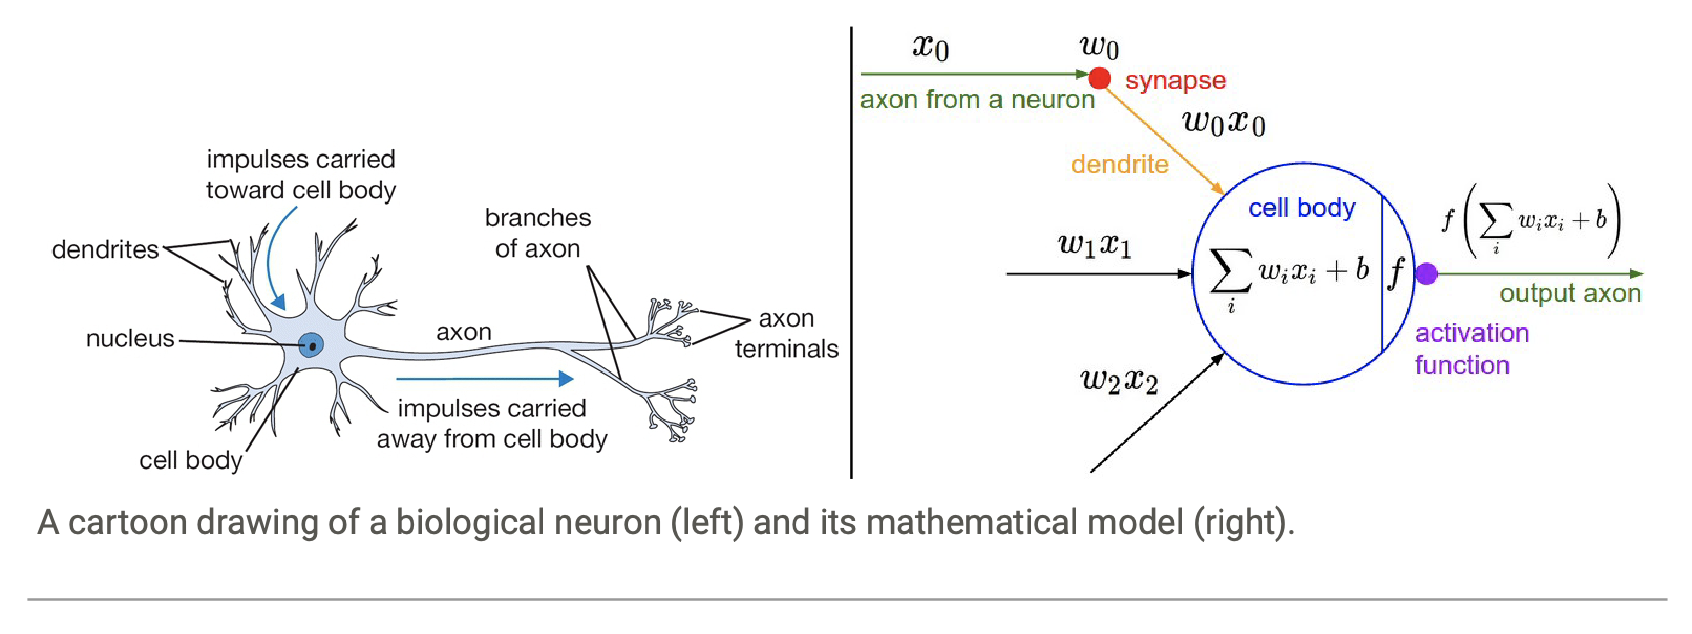

### 2.1 Activation Functionn Example: $$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

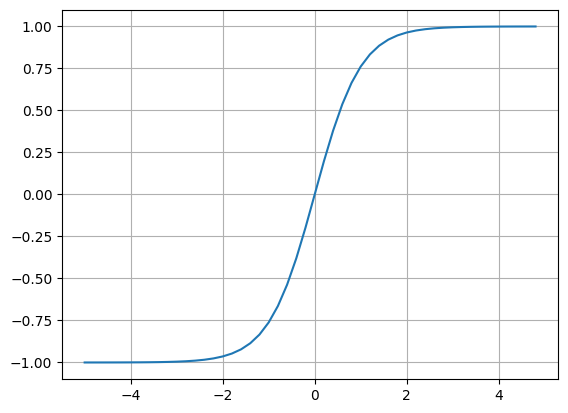

In [ ]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2))); plt.grid()

### 2.2 Computational Graph

In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights of neuron w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias b of neuron
b=Value(6.8813735870195432,label='b') # original example: b = Value(6.7, label='b')

# calculation of x1w1+x2w2+b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

# adding the bias gives unactivated output n (raw activation,cell body)
n = x1w1x2w2 + b; n.label = 'n'

# implement tanh as the activation function
o=n.tanh(); o.label='o'

### **Derivative Calculation**

### (1) Activation Layer
$$o = \tanh(n)$$
$$\frac{\partial o}{\partial n} = 1 - o^2$$

### (2) Addition Gate
$$n = (x_1w_1 + x_2w_2) + b$$
$$\frac{\partial o}{\partial b} = \frac{\partial o}{\partial n} \cdot 1$$
$$\frac{\partial o}{\partial (x_1w_1 + x_2w_2)} = \frac{\partial o}{\partial n} \cdot 1$$

### (3) Multiplication Gate
use $x_1, w_1$ as an example：
$$x_1w_1 = x_1 \cdot w_1$$
$$\frac{\partial o}{\partial x_1} = \frac{\partial o}{\partial x_1w_1} \cdot w_1$$
$$\frac{\partial o}{\partial w_1} = \frac{\partial o}{\partial x_1w_1} \cdot x_1$$

### (4) Chain Rule Example
claculate the gradient of $w_1$ to the output：
$$\frac{\partial o}{\partial w_1} = \underbrace{\frac{\partial o}{\partial n}}_{1-o^2} \cdot \underbrace{\frac{\partial n}{\partial (x_1w_1)}}_{1} \cdot \underbrace{\frac{\partial (x_1w_1)}{\partial w_1}}_{x_1}$$

### 2.2.1Manual Calculation Method

In [ ]:
o.grad=1.0

In [ ]:
o.data

0.7071067811865476

In [ ]:
# calculation of n.grad
1-o.data**2

0.4999999999999999

In [ ]:
n.grad=0.5

In [ ]:
x1w1x2w2.grad=0.5
b.grad=0.5

In [ ]:
x1w1.grad=0.5
x2w2.grad=0.5

In [ ]:
x1.grad=w1.data*x1w1.grad
w1.grad=x1.data*x1w1.grad


In [ ]:
x2.grad=w2.data*x2w2.grad
w2.grad=x2.data*x2w2.grad


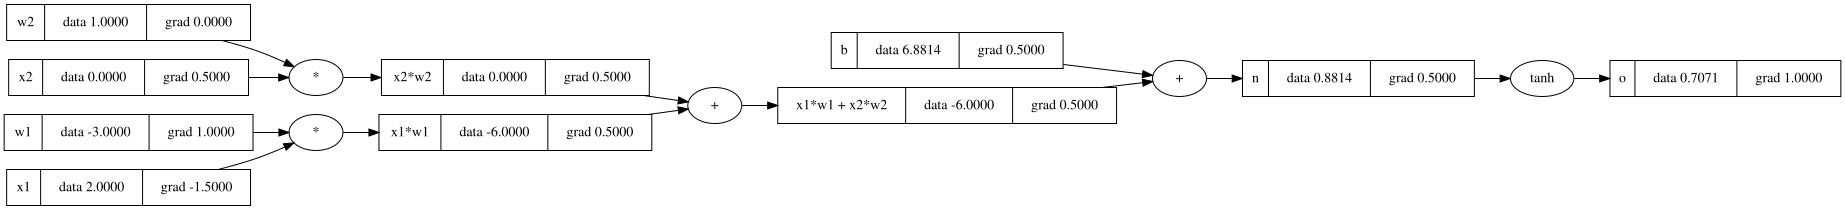

In [ ]:
draw_dot(o)

**The above is a manual calculation of the gradient in the Back Propagation Process**

**However, this can be very TEDIOUS.**

**Therefore, we can directly add functions in the Value Class**

**A quick method to memorize the Derivative calculation is the that (the derivative at a specific level)=(the local derivative)*(the derivative from the chain rule)**

### 2.2.2 _backward() function method

In [ ]:
# reset the graph so the _backward() function method starts from a clean state

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights of neuron w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias b of neuron
b=Value(6.8813735870195432,label='b') # original example: b = Value(6.7, label='b')

# calculation of x1w1+x2w2+b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

# adding the bias gives unactivated output n (raw activation,cell body)
n = x1w1x2w2 + b; n.label = 'n'

# implement tanh as the activation function
o=n.tanh(); o.label='o'

In [ ]:
# simplification: calling the _backward() function

o.grad=1.0 #initialize

In [ ]:
o._backward()

In [ ]:
n._backward()

In [ ]:
b._backward()

In [ ]:
x1w1x2w2._backward()

In [ ]:
x2w2._backward()
x1w1._backward()

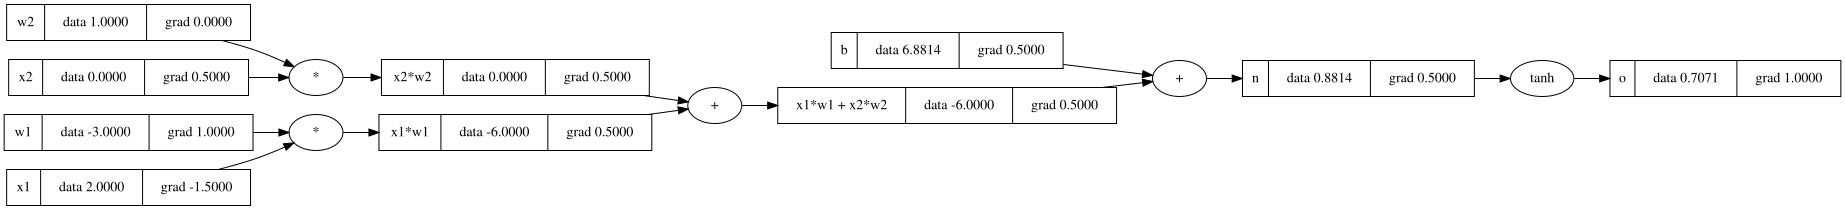

In [ ]:
draw_dot(o)

### 2.2.3 Topology Sort To Record Chain

In [ ]:
topo=[]
visited=set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo
# code should be added to the Value class

[Value(data=1.0,label=w2),
 Value(data=0.0,label=x2),
 Value(data=0.0,label=x2*w2),
 Value(data=2.0,label=x1),
 Value(data=-3.0,label=w1),
 Value(data=-6.0,label=x1*w1),
 Value(data=-6.0,label=x1*w1 + x2*w2),
 Value(data=6.881373587019543,label=b),
 Value(data=0.8813735870195432,label=n),
 Value(data=0.7071067811865476,label=o)]

### 2.2.4 Testing With Pytorch

In [ ]:
import torch

# 1. Define inputs and weights as PyTorch Tensors
# We use .double() to match the 64-bit precision of our manual class
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b  = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

# 2. Forward pass (building the graph)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# 3. Output the result of the forward pass
print(f"Forward pass output (o): {o.data.item()}")

# 4. Run Backpropagation
o.backward()

# 5. Inspect the gradients
print('--- Gradients Comparison ---')
print(f'x2 gradient: {x2.grad.item()}')
print(f'w2 gradient: {w2.grad.item()}')
print(f'x1 gradient: {x1.grad.item()}')
print(f'w1 gradient: {w1.grad.item()}')

Forward pass output (o): 0.7071066904050358
--- Gradients Comparison ---
x2 gradient: 0.5000001283844369
w2 gradient: 0.0
x1 gradient: -1.5000003851533106
w1 gradient: 1.0000002567688737


### 2.2.5 Neuro Network Module Test

In [ ]:
import math
import random
class Neuron:
    def __init__(self,nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    
    def __call__(self,x):
        # w*x+b
        act=sum((wi*xi for wi, xi in zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    
    def parameters(self):
        return self.w+[self.b]
    
class Layer:
    
    def __init__(self,nin, nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    
    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
# Example Dataset
x=[2.0,3.0,-1.0]
model=MLP(3,[4,4,1])
model(x)

Value(data=0.11327184821882844,label=)

In [ ]:
len(model.parameters())

41

In [ ]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys=[1.0,-1.0,-1.0,1.0]   # desired targets


[Value(data=0.11327184821882844,label=),
 Value(data=-0.6543676321525294,label=),
 Value(data=-0.3345894071572995,label=),
 Value(data=0.10632375693205567,label=)]

In [56]:
ypred=[model(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

TypeError: 'numpy.float64' object is not iterable

In [55]:
ypred=[model(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

TypeError: 'numpy.float64' object is not iterable

In [ ]:
loss.backward()

In [ ]:
model.layers[0].neurons[0].w[0].grad

0.0

In [ ]:
model.layers[0].neurons[0].w[0].data

-0.45989319128031436

In [53]:
for p in model.parameters():
    p.data+=-0.01*p.grad

In [54]:
model.layers[0].neurons[0].w[0].data

-0.45989319128031436